# A single-band approximation for La$_{2}$CuO$_{4}$: DMFT

In this tutorial, we will solve an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. Starting from a DFT calculation, we downfold the full band structure to a minimal correlated subspace using Wannier functions (see [Tutorial 1](01s-dft.ipynb)). We include strong local correlations beyond DFT within the single-site dynamical mean-field theory (DMFT) approximation and solve the resulting interacting model self-consistently. While single-site DMFT does not capture all features of cuprate physics (e.g., momentum-dependent self-energies or pseudogap behavior), it provides a foundational framework to understand spectral-weight transfer, quasiparticle renormalization, and Mott physics in a realistic setting.

**Specifically, you will learn how to construct and solve the DMFT equations using TRIQS/ModEST.**

## 🧠 DMFT loop from scratch

We will build a single-site DMFT script for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. 

**Your main goal for this tutorial is to fill in the following Python script. No need to start filling in the script now! You will fill in the example script, by completing each of the exercises in the notebook.**

```python
# total electron density
target_density = 1.0

# create one-body elements from atomic orbitals and TB Hamiltonian (see Exercise 1)
obe = 

# set up embedding (see Exercise 2)
E = 

# set up self-energy Sigma = 0 (see Exercise 3)
Sigma_imp_dynamic, Sigma_imp_infty = E.make_zero_imp_self_energy(mesh)[0]

n_dmft_loops = 2

# DMFT loop
for n_iter in range(n_dmft_loops):

    # embed self-energy (see Exercise 3)
    Sigma_C_dynamic, Sigma_C_infty = 

    # find mu (see Exercise 4)
    mu = 

    # compute the local Green's function (see Exercise 5)
    Gloc = 

    # compute impurity levels (see Exercise 6)
    hloc0 = 

    # compute hybridization function (see Exercise 6)
    Delta_iw = 
    
    # solve impurity problem (see Exercise 8)
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_infty = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree    
```

**Do not worry; we will proceed in stages, and we will put everything together in Exercise 9!**

### 🧪 Exercise 0: Import TRIQS/modest

Let's start by importing the TRIQS/modest module. Run: ``import triqs_modest as modest`` below.

In [1]:
import triqs_modest as modest

### 🧪 Exercise 1: Atomic orbitals and one-body elements
We'll start by loading the one-body elements (or obe for short) from the Wannier90 data (``lco_tb.dat`` in the ``data/mlwf/`` directory), which can be produced by following [Tutorial 1](01s-dft.ipynb). Let's use the function ``one_body_elements_from_wannier90`` to construct the ``obe`` object.

> 💡**Tip**: If you want to see the function signature without leaving the notebook to search the API, you can write
>
> ```
> ?name_of_function
> ```
>
> This will print the docstring for ``name_of_function``.

The one-body elements object takes three arguments: 
- the ``seedname`` of the Wannier90 data,
- the spin-kind indicating whether the Wannier90 data is spinful or spinless,
- a list of ``AtomicOrbs``

The atomic orbitals (``AtomicOrbs``) denote the orbital information corresponding to the Wannier functions that you have created. For your case of La$_{2}$CuO$_{4}$ with a single $d_{x^{2}-y^{2}}$ orbital, this translates to an ``AtomicOrbs`` with dimension 1 (``dim=1``). Since it's a $d$ orbital we use angular momentum $l=2$. Finally, our Wannier function corresponds to a single Cu site, so we label this orbital with ``dft_idx=0`` and ``cls_idx=0``.

#### ❓How would the ``AtomicOrbs`` change with more orbitals?
| Scenario | N orbitals | ``AtomicOrbs`` |
|:---------:|:---------:|:---------------:|
| Wannier function for Cu-$d_{x^{2}-y^{2}}$ | 1 | ``AtomicOrbs(dft_idx=0, cls_idx=0, dim=1, l=2)``|
| Wannier functions for Cu-$e_{g}$ | 2 | ``AtomicOrbs(dft_idx=0, cls_idx=0, dim=2, l=2)``|
| Wannier functions for Cu($3d$) | 5 | ``AtomicOrbs(dft_idx=0, cls_idx=0, dim=5, l=2)``|
| Wannier functions for Cu($3d$), O($2p$) | 17 | ``[AtomicOrbs(dft_idx=0, cls_idx=0, dim=5, l=2), AtomicOrbs(dft_idx=1, cls_idx=1, dim=3, l=1), AtomicOrbs(dft_idx=2, cls_idx=1, dim=3, l=1), AtomicOrbs(dft_idx=4, cls_idx=1, dim=3, l=1)]``|

In [ ]:
?modest.one_body_elements_from_wannier90

In [2]:
wannier_file_path = "../data/mlwf/lco"
spin_kind         = "NonPolarized"
atomic_orbitals   = [modest.AtomicOrbs(dft_idx=0, cls_idx=0, l=2, dim=1)]
obe               = modest.one_body_elements_from_wannier90(wannier_file_path, spin_kind, atomic_orbitals)
print(obe.C_space)

Local space [orbital_set]:
  Total dimension [M]: 1
  Number of correlated atoms: 1
  Number of inequivalent correlated atoms = 1
  Atomic decomposition:
     dim_a:   1
         a:   0
    irreps: [1]



### 🧪 Exercise 2: Make an Embedding
Use the function ``make_embedding`` to initialize the embedding class and print it out. This function takes as an argument the local space, which is a member of ``obe``.

> 💡 **Tip:** Remember that you can access members of a class in Python by writing ``Object.method(...)`` or ``Object.property``.

After printing out the Embedding, pause, and take a moment to read the output. What does it tell you? Recall that the embedding object maps the impurity self-energies back to the lattice and maps the local Green's functions back to the impurities. For such a simple case, this mapping is one-to-one, but we will see later on that this mapping can become more complex.

In [3]:
E = modest.make_embedding(obe.C_space)
print(E)

Embedding: 1 impurities
  Σ_embed block decomposition:
    dim_α:   1
        α:   0

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0



### 🧪 Exercise 3: Set up an empty self-energy and embedding

Now that we have an ``Embedding``, we can use that object to prepare our starting impurity self-energies. The embedding class has a method ``make_zero_imp_self_energies``, which returns a list of self-energies (each decomposed into [dynamic, static] parts) given a TRIQS mesh with the data initialized to zero. Use this function to create the impurity self-energies and print them to the screen.

> 💡 **Tip:** You will be returned a list, but since we are only working with a single impurity you can capture the first element of the returned list.

As a second step, try embedding these self-energies into the larger space. You can do this using the ``embed`` method of the embedding class. It takes as arguments a list of dynamic self-energies and a list of static self-energies. 

Print the embedded self-energy to the screen.

In [4]:
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

Sigma_imp_dynamic, Sigma_imp_infty = E.make_zero_imp_self_energies(mesh)[0]
Sigma_imp_dynamic, Sigma_imp_infty

(Green Function G composed of 2 blocks: 
  Greens Function G_up_0 with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
  
  Greens Function G_down_0 with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
  ,
 [array([[0.+0.j]]), array([[0.+0.j]])])

In [5]:
Sigma_C_dynamic, Sigma_C_infty = E.embed([Sigma_imp_dynamic], [Sigma_imp_infty])
Sigma_C_dynamic, Sigma_C_infty

(Green's Function  composed of 2 2-index blocks: 
  Greens Function ('0', 'up') with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
  
  Greens Function ('0', 'down') with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
  ,
 array([[array([[0.+0.j]]), array([[0.+0.j]])]], dtype=object))

> 🧠 **Think:** Why do we separate the self-energy into a dynamic and a static part? The dynamic part is obviously a function of frequency, while the static part corresponds to $\Sigma_{\infty}$ (i.e.., the value of the self-energy as $\Sigma(\omega \rightarrow \infty)$).

### 🧪 Exercise 4: Chemical Potential
Let's find the chemical potential that corresponds to our target total electron density. For this use the function ``find_chemical_potential``.

In [6]:
opt = modest.BzIntOptions(k_grid = [7,7,7], run_adaptive=False) # k-summation options

target_density = 1.0 # total electron density

mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_infty, opt, verbosity=False)

### 🧪 Exercise 5: Compute the local Green's function and extract impurity quantities
Now that we have the chemical potential, we can compute the local Green's function. Recall, the local Green's function is generically defined as

$$ [G_{\mathrm{loc}}(\omega)]_{m m'}^{\sigma} = \sum_{\mathbf{k}} P^{\sigma}_{m\nu}(\mathbf{k})\Big [ (\omega + \mu )\delta_{\nu\nu'} - H^{\sigma}_{\nu\nu'}(\mathbf{k}) - [P^{\sigma}_{m\nu}(\mathbf{k})]^{\dagger}\Sigma_{\mathrm{embed}}P^{\sigma}_{m'\nu'}(\mathbf{k})\Big ]^{-1} [ P^{\sigma}_{m'\nu'}(\mathbf{k})]^{\dagger}.$$

We will use the local Green's function below for the self-consistency condition and to construct the hybridization function, $\Delta(i\omega_{n})$.

The local Green's function is expressed in the larger $\cal{C}$ space, meaning that hthe index $m$ in the equation above runs over all localized orbitals to which electronic correlations are applied. We now want to obtain the Green's functions corresponding to each impurity to be solved. The embedding class provides an ``extract`` method which, given a Green's function in the $\cal{C}$ space, returns a list of Green's function with the appropriate block structure for the _unique_ impurity solver(s).

In [7]:
Gloc_C = modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_infty, opt)
print(Gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function ('0', 'down') with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
 



In [8]:
Gloc = E.extract(Gloc_C)[0]
print(Gloc)

Green Function G composed of 2 blocks: 
 Greens Function G_up_0 with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function G_down_0 with mesh Imaginary frequency mesh with beta = 10, statistics = Fermion, N_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 6: Impurity Levels and Hybridization function

The central inputs to the impurity solver are the impurity levels ($\varepsilon_{d}$) and the hybridization function ($\Delta(i\omega_{n})$). In this exercise, you will calculate both. The impurity levels correspond to

$$ [\varepsilon_{d}]_{m m'} = \sum_{\mathbf{k}} P_{m\nu}(\mathbf{k}) H_{\nu\nu'}(\mathbf{k}) P^{\dagger}_{m'\nu'}(\mathbf{k}) - \mu\,\delta_{mm'}, $$
where $\mu$ is the chemical potential. We can compute the impurity levels with the function ``impurity_levels``, which takes ``obe`` as an argument.

The hybridization function is defined as

$$ \Delta(\omega) = \omega - \varepsilon_{d} - \mathcal{G}_{0}^{-1}(\omega), $$

where $\mathcal{G}_{0} = \big((G_{\text{loc}})^{-1} + \Sigma\big)^{-1}$. The hybridization function can be computed using the function ``hybridization``.

In [9]:
# impurity levels in the C space - the chemical potential
hloc0_C = modest.impurity_levels(obe) - mu

# Extract the local levels
hloc0 = E.extract(hloc0_C)[0]

# compute Δ using hloc0, Gloc, and the impurity self-energy
Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_infty)

### 🧪 Exercise 7: Plot the DFT local Green's function and Hybridization functions

Before starting the DMFT calculation, let's plot the local Green's function and hybridization functions obtained from DFT.

> 💡**Tip:** Use the ``oplot`` function in ``triqs.plot.mpl_interface`` for quick plotting.

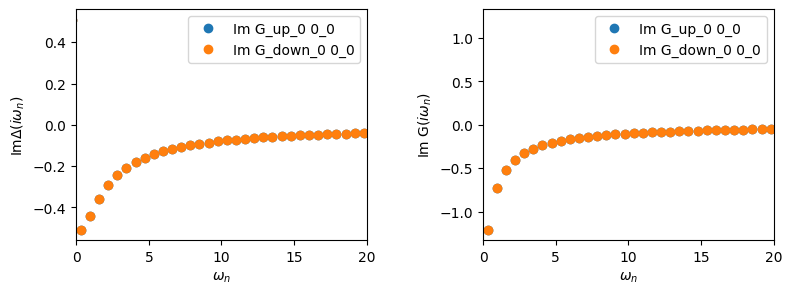

In [10]:
from triqs.plot.mpl_interface import oplot, plt

fig, ax = plt.subplots(1,2, sharex=True, figsize=(9,3))
oplot(Delta_iw.imag, 'o', axes=ax[0]); ax[0].set_ylabel(r'Im$\Delta(i\omega_{n})$')
oplot(Gloc.imag, 'o', axes=ax[1]);
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.4)
plt.show()

### 🧪 Exercise 8: Define the interaction and solver parameters
We need to define the interaction Hamiltonian for our impurity model. For our model, this is:

$$ H_{\text{int}} = U n_{\uparrow} n_{\downarrow}.$$

Use the many-body operators within the TRIQS library to construct this interaction. Let's take $U$ = 3.6 eV.

> 💡 **Tip**: The many-body operators must match between all of your Green's functions.

In [11]:
from triqs.operators import n
from triqs_tutorials_utils.triqs_cthyb.solver import solve

solver_params = dict(length_cycle=80, n_cycles = int(1e+6), n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=5, fit_max_w=9, imag_threshold = 1e-6)

U = 3.6
h_int = U*n('up_0',0)*n('down_0',0)

Starting serial run at: 2025-08-22 14:08:34.804126


> ⚠️ **Caution:** You are using a prototype interface to the TRIQS/cthyb solver. We have included the prototype as part of this set of tutorials, which we import from the ``triqs_tutorials_utils.triqs_cthyb.solver`` module. **This is not yet part of the TRIQS library.** For your own research calculations, you can copy this function to your project or use the current interface to the TRIQS/cthyb solver.

### 🧪 Exercise 9: Write the DMFT loop

You now have all the pieces to write the DMFT self-consistency loop. Your task is to fill in the steps that occur during each DMFT iteration. This includes solving the impurity problem and updating the self-energy, chemical potential, Green's function, and hybridization function.

#### 🧩 Your task
Fill in the provided pseudocode to perform the following steps for each DMFT iteration:

For each iteration of the DMFT loop, do:
1. Embed the self-energy
2. Find the chemical potential
3. Compute the local Green's function
4. Compute the impurity levels
5. Update the hybridization function
6. Solve the impurity problem
7. Update the impurity self-energy

In [12]:
n_dmft_loops = 2

# DMFT loop
for n_iter in range(n_dmft_loops):

    # 1. embed self-energy (see Exercise 3)
    Sigma_C_dynamic, Sigma_C_infty  = E.embed([Sigma_imp_dynamic], [Sigma_imp_infty])

    # 2. find mu (see Exercise 4)
    mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_infty, opt, verbosity=False)

    # 3. compute the local Green's function and extract (see Exercise 5)
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_infty, opt))[0]

    # 4. compute impurity levels (see Exercise 6)
    hloc0 = E.extract(modest.impurity_levels(obe) - mu)[0]

    # 5. compute hybridization function (see Exercise 6)
    Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_infty)
    
    # 6. solve impurity problem (see Exercise 8)
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # 7. update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_infty = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree

Δn = |n_lattice - n_impurity| = 0.4765232956628921
╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:

0.08932*c_dag('down_0',0)*c('down_0',0) + 0.08932*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
14:08:56 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
14:08:56   0% ETA 00:01:05 cycle 1520 of 1000000
14:08:58   3% ETA 00:01:03 cycle 32316 of 1000000
14:09:01   7% ETA 00:01:01 cycle 70682 of 1000000
14:09:04  11% ETA 00:00:58 cycle 118680 of 1000000
14:09:08  17% ETA 00:00:54 cycle 177626 of 1000000
14:09:13  25% ETA 00:00:49 cycle 254393 of 1000000
14:09:19  34% ETA 00:00:42 cycle 348780 of 1000000
14:09:27  46% ETA 00:00:34 cycle 466745 of 1000000
14:09:36  61% ETA 00:00:25 cycle 615772 of 1000000
14:09:48  79% ETA 00:00:13 cycle 797636 of 1000

### 🧪 Exercise 10: Plot results from your DMFT iteration
Let us plot the results obtained after a couple of DMFT iterations. Specifically, let's look at the impurity Green's function and the impurity self-energy. The ``solver_results`` container exposes the impurity Green's function as ``.G_iw`` and the impurity self-energy as ``.Sigma_iw``.

> 💡**Tip:** Try using ``oplot`` again for making quick plots.

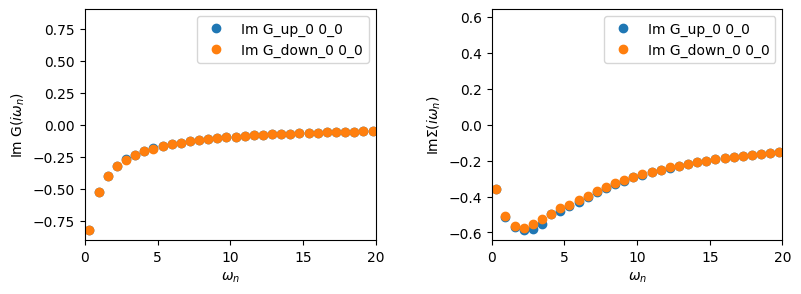

In [13]:
fig, ax = plt.subplots(1,2, sharex=True, figsize=(9,3))
oplot(solver_results.G_iw.imag, 'o', axes=ax[0]);     
oplot(solver_results.Sigma_iw.imag, 'o', axes=ax[1]); ax[1].set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.4)
plt.show()

## 🎉 Congratulations!

You've just written your own DMFT script using TRIQS and TRIQS/ModEST to perform realistic DMFT calculations for materials. Next, we will learn how to post-process these results.